# **Rock Paper Scissors**

---



### **Overview**


Welcome. Today you will go back to your childhood. We will play rock, paper, scissors! You can find an overview of our journey at this [link](https://edison-chen.notion.site/Rock-Paper-Scissors-w-Computer-Vision-CNNs-434b4dd7571e477fb7c53060f788508b?pvs=74).

### **Dataset**

We will use the following dataset to train our model. The dataset contains 14966 training, 588 validation, and 320 test images, all of which belong to either rock, paper, scissors, or irrelevant class.

In [ ]:
!curl -L https://app.roboflow.ai/ds/h6I8GnXgie?key=gKKAX8LVWV | jar -x

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    68  100    68    0     0    116      0 --:--:-- --:--:-- --:--:--   116
100   896  100   896    0     0    691      0  0:00:01  0:00:01 --:--:--  3612
 99  808M   99  803M    0     0  26.1M      0  0:00:30  0:00:30 --:--:-- 30.2M
curl: (23) Failure writing output to destination


Here, we will import all the necessary base libraries

In [ ]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn.functional as F

import random
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.facecolor'] = '#ffffff'

from PIL import Image
import os

### **Reorganizing the Dataset**
For further convenience, we setup our custom DataSet Class to be compatible for later calculations

In [ ]:
class RockPaperScissorsDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = sorted([file for file in os.listdir(directory) if file.endswith('.jpg')])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = os.path.join(self.directory, self.images[idx])
        image = Image.open(img_name)

        label_file = img_name.replace('.jpg', '.txt')
        labels = []
        bboxes = []

        if os.path.getsize(label_file) == 0:  # Check if the .txt file is empty
          labels.append(-1)  # Special label for no object
          bboxes.append([0, 0, 0, 0])  # Dummy bbox
        else:
            with open(label_file, 'r') as f:
                for line in f:
                    line = line.strip().split(' ')
                    label = int(line[0])
                    bbox = [float(coord) for coord in line[1:]]

                    labels.append(label)
                    bboxes.append(bbox)

        sample = {
            'image': image,
            'labels': torch.tensor(labels),
            'bboxes': torch.tensor(bboxes)
        }

        if self.transform:
            sample['image'] = self.transform(sample['image'])

        return sample

PyTorch's default collate function, used by the DataLoader, expects each item in a batch to have the same shape. However, in our dataset, different images have a different number of objects, leading to a variable number of labels and bounding boxes for each image.

Also, since there are varying number of bounding boxes, we will pad the bounding boxes to match the sizes.

In [ ]:
def pad_bboxes(bboxes, max_bbox_count, pad_value=0):
    padded_bboxes = [torch.cat([bbox, torch.full((max_bbox_count - bbox.shape[0], 4), pad_value)])
                     if bbox.shape[0] < max_bbox_count else bbox for bbox in bboxes]
    return torch.stack(padded_bboxes)

def custom_collate_fn(batch):
    images = [item['image'] for item in batch]
    labels_list = [item['labels'] for item in batch]
    bboxes_list = [item['bboxes'] for item in batch]

    images = torch.stack(images)
    num_classes = 4

    # Initialize an empty tensor for labels of the shape: (batch_size, num_classes)
    batch_labels = torch.zeros((len(labels_list), num_classes))

    for i, labels in enumerate(labels_list):
        for label in labels:
            if label >= 0:  # Check to ignore dummy labels like -1
                batch_labels[i, label] = 1  # Set the corresponding label index to 1

    max_bbox_count = max(len(bboxes) for bboxes in bboxes_list)  # Calculate max bbox count
    padded_bboxes = pad_bboxes(bboxes_list, max_bbox_count)
    batched_data = {
        'image': images,
        'labels': batch_labels,
        'bboxes': padded_bboxes,
        'max_bbox_count': max_bbox_count
    }

    return batched_data

loss_fn = torch.nn.BCEWithLogitsLoss()

In [ ]:
from torch.utils.data import DataLoader
import torchvision
data_transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])


train_dir = '/content/train/'
val_dir = '/content/valid/'
test_dir = '/content/test/'

# Instantiate the datasets
train_dataset = RockPaperScissorsDataset(directory=train_dir, transform=data_transforms)
val_dataset = RockPaperScissorsDataset(directory=val_dir, transform=data_transforms)
test_dataset = RockPaperScissorsDataset(directory=test_dir, transform=data_transforms)

As a test, let's display one instance of the training set along with its label and bounding box

In [ ]:
import matplotlib.patches as patches

label_info = {
    0: {'name': 'Paper', 'color': 'blue'},
    1: {'name': 'Rock', 'color': 'brown'},
    2: {'name': 'Scissors', 'color': 'green'}
}

def show_image_with_bbox(dataset, index, image_size=640):
    # Retrieve the image and its bounding box from the dataset
    sample = dataset[index]
    image = sample['image']
    labels = sample['labels']
    bboxes = sample['bboxes']

    if isinstance(image, torch.Tensor):
        # Convert to a numpy array and ensure it's in the range [0, 1] for displaying
        image = image.permute(1, 2, 0).numpy()
        image = (image - image.min()) / (image.max() - image.min())

    # Create a new figure and axis for plotting
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # Iterate through all bounding boxes and labels
    for label, bbox in zip(labels, bboxes):
        if label < 0:  # Skip if label indicates 'no object'
            continue

        # Denormalize the bounding box coordinates
        x_center, y_center, width, height = bbox
        x_center *= image_size
        y_center *= image_size
        width *= image_size
        height *= image_size

        # Calculate the upper left corner
        x_upper_left = x_center - (width / 2)
        y_upper_left = y_center - (height / 2)

        # Get the label info using the label_info dictionary
        label_name = label_info[label.item()]['name']
        color = label_info[label.item()]['color']

        # Create a Rectangle patch with the corresponding color
        rect = patches.Rectangle((x_upper_left, y_upper_left), width, height, linewidth=2, edgecolor=color, facecolor='none')

        # Add the bounding box to the Axes
        ax.add_patch(rect)

        # Display the label name with the corresponding color
        ax.text(x_upper_left, y_upper_left - 10, f'{label_name}', color='white', fontsize=12, backgroundcolor=color)

    # Remove axis ticks
    plt.axis('off')
    plt.show()


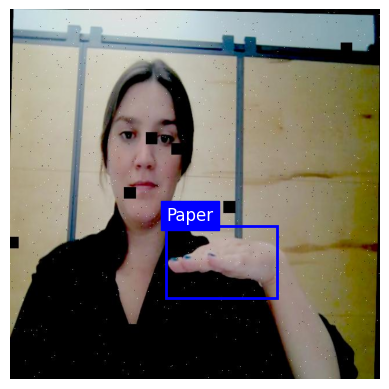

In [ ]:
index_to_display = random.randint(1, 14966)
show_image_with_bbox(train_dataset, index_to_display)

Now let's display the first batch of the training data

In [ ]:
from torchvision.utils import make_grid

def show_batch_collate_fn(batch):
    images = [item['image'] for item in batch]
    labels_list = [item['labels'] for item in batch]
    bboxes_list = [item['bboxes'] for item in batch]

    # Stack images into a single tensor
    images = torch.stack(images)

    # Now, each element in the batch will be a dictionary with its labels and bounding boxes
    batched_data = {
        'image': images,
        'labels': labels_list,
        'bboxes': bboxes_list
    }

    return batched_data

def show_batch(dl, label_info=label_info, image_size=640):
    batch = next(iter(dl))
    images, labels_batch, bboxes_batch = batch['image'], batch['labels'], batch['bboxes']

    # Create a grid of images using make_grid
    grid = make_grid(images, nrow=8)
    fig, ax = plt.subplots(figsize=(25, 25))

    # Convert grid to a NumPy image for display
    grid_np = torchvision.transforms.functional.to_pil_image(grid)
    ax.imshow(np.asarray(grid_np))

    # Calculate the size of each image in the grid (assuming square images)
    grid_img_size = image_size + 2  # 2 for the default padding in make_grid

    for img_idx, (labels, bboxes) in enumerate(zip(labels_batch, bboxes_batch)):
        # Get the image location in the grid
        row = img_idx // 8
        col = img_idx % 8

        # Go through each label and bbox for the current image
        for label, bbox in zip(labels, bboxes):
            if label == -1:  # Skip if label indicates 'no object'
                continue

            # Denormalize the bounding box coordinates
            x_center, y_center, width, height = bbox
            x_center *= image_size
            y_center *= image_size
            width *= image_size
            height *= image_size

            # Calculate the upper left corner considering the location in the grid
            x_upper_left = x_center - (width / 2) + col * grid_img_size
            y_upper_left = y_center - (height / 2) + row * grid_img_size

            # Get the label info using the label_info dictionary
            label_name = label_info[label.item()]['name']
            color = label_info[label.item()]['color']

            # Create a Rectangle patch with the corresponding color
            rect = patches.Rectangle((x_upper_left, y_upper_left), width, height,
                                     linewidth=2, edgecolor=color, facecolor='none')

            # Add the bounding box to the Axes
            ax.add_patch(rect)

            # Display the label name with the corresponding color
            ax.text(x_upper_left, y_upper_left - 10, f'{label_name}',
                    color='white', fontsize=12, backgroundcolor=color)

    # Remove axis ticks and display the grid
    ax.axis('off')
    plt.show()

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, collate_fn=show_batch_collate_fn)
show_batch(train_loader)

In [ ]:
print(len(train_dataset), len(val_dataset), len(test_dataset))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, num_workers=2, pin_memory=True, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=2, num_workers=2, pin_memory=True, collate_fn=custom_collate_fn)
print(len(train_loader), len(val_loader), len(test_loader))

14966 588 320
468 294 160


To better use a GPU we will use the helper functions and class used in one of the assignments

In [ ]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) or dictionary of tensors to chosen device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    elif isinstance(data, dict):
        return {k: to_device(v, device) if torch.is_tensor(v) else v for k, v in data.items()}
    elif torch.is_tensor(data):
        return data.to(device, non_blocking=True)
    else:
        return data

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

### **Classification**


We know create our base class for our classification class

In a multi-label classification context, calculating accuracy as for a single-label classification scenario is not straightforward or necessarily meaningful. This is because, in multi-label classification, each label in the output can be considered an independent binary classification. Therefore, it is more practical to use F1 score.

In [ ]:
class ClassificationBase(nn.Module):

    def training_step(self, batch, max_bbox_count):
        images, labels, bboxes, max_bbox_count = batch['image'], batch['labels'], batch['bboxes'], batch['max_bbox_count']
        class_logits, bbox_coords = self(images, max_bbox_count)
        class_loss = F.binary_cross_entropy_with_logits(class_logits, labels)
        bbox_loss = F.mse_loss(bbox_coords, bboxes)
        total_loss = class_loss + bbox_loss
        return total_loss

    def validation_step(self, batch, max_bbox_count):
        images, labels, bboxes, max_bbox_count = batch['image'], batch['labels'], batch['bboxes'], batch['max_bbox_count']
        bboxes = torch.stack(bboxes) if isinstance(bboxes, list) else bboxes  # Convert bboxes list to tensor
        class_logits, bbox_coords = self(images, max_bbox_count)
        class_loss = F.binary_cross_entropy_with_logits(class_logits, labels)
        bbox_loss = F.mse_loss(bbox_coords, bboxes)
        total_loss = class_loss + bbox_loss
        f1 = calculate_f1_score(class_logits, labels)
        return {'val_loss': total_loss.detach(), 'val_f1': f1}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_f1s = [x['val_f1'] for x in outputs]
        epoch_f1 = torch.stack(batch_f1s).mean()
        return {'val_loss': epoch_loss.item(), 'val_f1': epoch_f1.item()}


    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_f1']))


from sklearn.metrics import f1_score

def calculate_f1_score(outputs, labels):
    preds = outputs.sigmoid() > 0.5
    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return torch.tensor(f1)

Now for our network creation. We have to output bigger feutures for our bounding box regressor from the base layer so that we can deal with varying length of tensors of the boudning boxes in each batch.


Since we are dealing with 640x640 images, we have to use bigger filters. We note that this is because there is a tradeoff between network size and computation capacity.

In [ ]:
class Classification(ClassificationBase):
    def __init__(self):
        super().__init__()
        self.base_layer = nn.Sequential(
            # input: 3 x 640 x 640
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            # output: 32 x 640 x 640
            nn.ReLU(),
            # output: 32 x 640 x 640
            nn.MaxPool2d(2, 2),
            # output: 32 x 320 x 320
            nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=1),
            # output: 16 x 320 x 320
            nn.ReLU(),
            # output: 16 x 320 x 320
            nn.MaxPool2d(2, 2),
            # output: 16 x 160 x 160

            nn.Conv2d(16, 32, kernel_size=16, stride=2, padding=1),
            # output: 32 x 74 x 74
            nn.ReLU(),
            # output: 32 x 74 x 74
            nn.Conv2d(32, 64, kernel_size=14, stride=2, padding=1),
            # output: 64 x 32 x 32
            nn.ReLU(),
            # output: 64 x 32 x 32
            nn.MaxPool2d(2, 2),
            # output: 64 x 16 x 16

            nn.Conv2d(64, 128, kernel_size=7, stride=1, padding=1),
            # output: 128 x 12 x 12
            nn.ReLU(),
            # output: 128 x 12 x 12
            nn.Conv2d(128, 256, kernel_size=7, stride=1, padding=1),
            # output: 256 x 8 x 8
            nn.ReLU(),
            # output: 256 x 8 x 8
            nn.MaxPool2d(2, 2),
            # output: 256 x 4 x 4

            nn.Flatten(),
            nn.Linear(4096, 1024),
            # output: 1024
            nn.ReLU(),
            # output: 1024
            nn.Linear(1024, 512),
            # output: 512
            nn.ReLU())
            # output: 512

        self.classifier = nn.Linear(512, 4)
        self.regressor = nn.Linear(512, 512)

    def forward(self, xb, max_bbox_count):
        features = self.base_layer(xb)
        class_logits = self.classifier(features)
        bbox_coords = self.regressor(features)

        bbox_coords = bbox_coords.view(xb.size(0), max_bbox_count, 4)

        return class_logits, bbox_coords


We will use learning rate scheduler - a technique that changes the learning rate over the course of training according to a predefined strategy. This technique is used to:

> Avoid Overfitting: A high learning rate at the beginning of training helps the model to learn fast, but as training progresses, reducing the learning rate helps the model to converge by making finer updates to the weights.

> Improve Convergence: Sometimes, a model might get stuck in a local minimum with a constant learning rate. Reducing the learning rate can help the model to escape local minima and find a better minimum



In [ ]:
def evaluate(model, val_loader):
    model.eval()
    outputs = []
    for batch in val_loader:
        max_bbox_count = batch['max_bbox_count']
        outputs.append(model.validation_step(batch, max_bbox_count))
    return model.validation_epoch_end(outputs)


def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            max_bbox_count = batch['max_bbox_count']
            loss = model.training_step(batch, max_bbox_count)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.detach())

        scheduler.step()  # Adjust the learning rate

        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)

    return history


In [ ]:
test_model = Classification()
device = get_default_device()
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)

In [ ]:
test_model.eval()  # Set the model to evaluation mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_model.to(device)  # Move the model to the appropriate device

Classification(
  (base_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(16, 16), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(32, 64, kernel_size=(14, 14), stride=(2, 2), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(64, 128, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): Conv2d(128, 256, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (14): ReLU()
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (16): Flatten(start_dim=1, end_dim=-1)
    (17): Linear(in

# Problems Arise
As a check, we wanted to input the first batch to the model and check its output shape. However, the methods are not correctly dealing with varying length of tensors.

In [ ]:
with torch.no_grad():  # Disable gradient calculation
    for batch in train_loader:
        images = batch['image'].to(device)
        max_bbox_count = batch['max_bbox_count']

        # If labels are a list of tensors, move each tensor to the device
        if isinstance(batch['labels'], list):
            labels = [label.to(device) for label in batch['labels']]
        else:
            labels = batch['labels'].to(device)  # Move labels to the device

        # Move bounding boxes to the device
        if isinstance(batch['bboxes'], list):
            bboxes = [bbox.to(device) for bbox in batch['bboxes']]
        else:
            bboxes = batch['bboxes'].to(device)

        print('images.shape:', images.shape)
        class_logits, bbox_preds = test_model(images, max_bbox_count)
        print('logits.shape:', class_logits.shape)
        print('logits[0]:', class_logits[0])

        print('bbox_preds.shape:', bbox_preds.shape)
        print('bbox_preds[0]:', bbox_preds[0])
        break


images.shape: torch.Size([32, 3, 640, 640])


RuntimeError: ignored

Before we begin training, let's initialize the model and see how it performs on the validation set with the initial set of parameters.

In [ ]:
model = Classification()
device = get_default_device()
model.to(device)
evaluate(model, val_loader)

In [ ]:
num_epochs = 20
lr = 0.001

The same problem as the check process above rises here. The mismatch of the tensors is the sole problem creator.

In [ ]:
history = fit(num_epochs, lr, model, train_loader, val_loader)

<ipython-input-152-383ade1d5fc2>:7: UserWarning: Using a target size (torch.Size([32, 4, 4])) that is different to the input size (torch.Size([16, 4, 4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  bbox_loss = F.mse_loss(bbox_coords, bboxes)


RuntimeError: ignored

In [ ]:
def plot_accuracies(history):
    accuracies = [x['val_f1'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs')

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs')

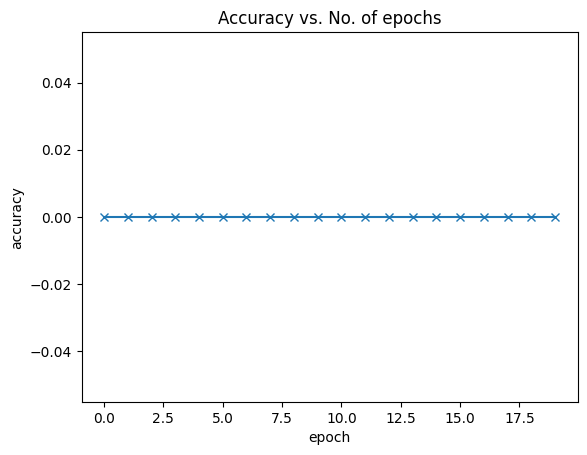

In [ ]:
plot_accuracies(history)

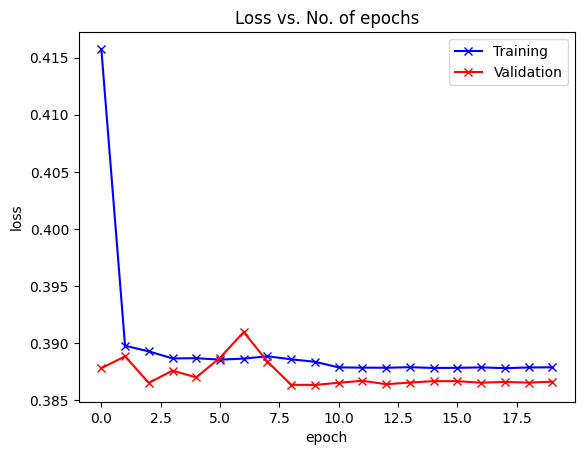

In [ ]:
plot_losses(history)

In [ ]:
model_state = model.state_dict()
torch.save(model_state, 'GG.pth')
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p '/content/drive/My Drive/Final Project'
torch.save(model_state, '/content/drive/My Drive/Final Project/GG.pth')


Mounted at /content/drive


In [ ]:
test_loader = DeviceDataLoader(test_loader, device)
result = evaluate(model, test_loader)
result

{'val_loss': 0.38493451476097107, 'val_f1': 0.0}

_______________________________

### **Comparing our model with a pre-trained model**

We will use YouOnlyLookOnce algorithm. So clone it from github

In [ ]:
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 16111, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 16111 (delta 6), reused 9 (delta 1), pack-reused 16089
Receiving objects: 100% (16111/16111), 14.84 MiB | 24.19 MiB/s, done.
Resolving deltas: 100% (11025/11025), done.
/content/yolov5


Install the relevant requirements

In [ ]:
!pip install -r requirements.txt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.6/190.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.2/661.2 kB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: Pillow 9.4.0
    Uninstalling Pillow-9.4.0:
      Successfully uninstalled Pillow-9.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imageio 2.31.6 requires pillow<10.1.0,>=8.3.2, but you have pillow 10.1.0 which is incompatible.


In [ ]:
%%writefile dataset.yaml
train: /content/train/
val: /content/train/

nc: 3  # number of classes
names: ['Rock', 'Paper', 'Scissors']

Writing dataset.yaml


Feed the pre-trained model with our training dataset

In [ ]:
!python train.py --img 640 --batch 32 --epochs 5 --data dataset.yaml --weights yolov5s.pt --cache


2023-12-19 20:31:14.277670: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-19 20:31:14.277721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-19 20:31:14.279084: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5s.pt, cfg=, data=dataset.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=5, batch_size=32, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs

Choose the best weight and check the test set

In [ ]:
!python detect.py --weights runs/train/exp2/weights/best.pt --img 640 --conf 0.25 --source /content/test/


detect: weights=['runs/train/exp2/weights/best.pt'], source=/content/test/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-253-g63555c8 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
image 1/320 /content/test/10e0gvm_jpg.rf.3b68a834fab647f30a57fc3ea92d4cd2.jpg: 640x640 (no detections), 11.6ms
image 2/320 /content/test/15208484cellblock_jpg.rf.95cbda1e169a66105fbf2aa22959a73b.jpg: 640x640 (no detections), 11.6ms
image 3/320 /content/test/19171_298_298_1_0_jpg.rf.0024dfb25d7b5a13a78e94fca47ef004.jpg: 640x640 (no d

As Yolo already saves the best and latest weights along with relevant results to te directory, we can use the custom model to predict custom images.

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
YOLOv5 🚀 2023-12-20 Python-3.10.12 torch-2.1.0+cu121 CPU

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


Saving test_image_1.png to test_image_1 (2).png
Saving test_image_2.png to test_image_2 (2).png


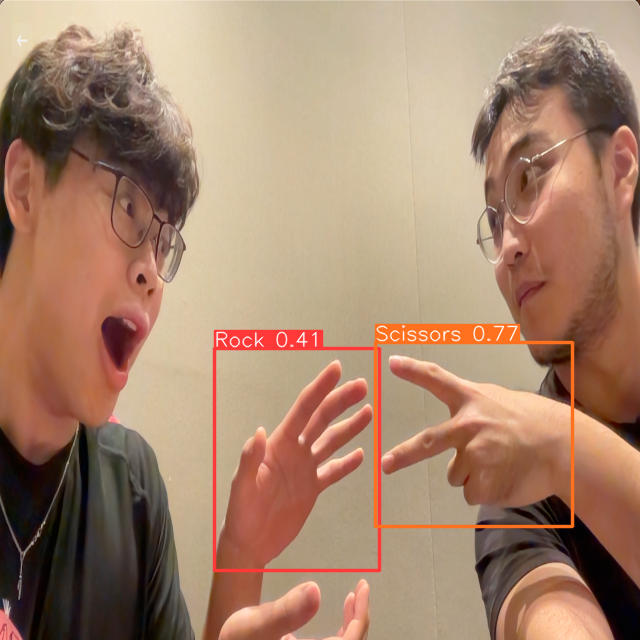

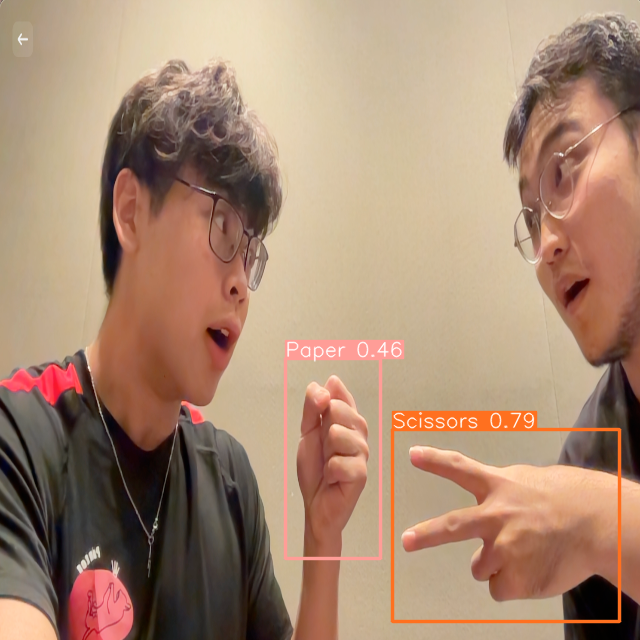

In [ ]:
from google.colab import files
import torch
import os

custom_dir = '/content/custom/'
if not os.path.exists(custom_dir):
    os.makedirs(custom_dir)

#model_path = '/content/yolov5/runs/train/exp2/weights/best.pt'
model_path = '/content/best.pt'
best_model = torch.hub.load('ultralytics/yolov5', 'custom', path=model_path, force_reload=True)

uploaded = files.upload()
for filename in uploaded.keys():

    with open(custom_dir + filename, 'wb') as f:
        f.write(uploaded[filename])

    img_path = custom_dir + filename
    results = best_model(img_path)

    results.show()
